# HR Analytics: Exploratory Data Analysis

**Business goal:**  
Analyze employee data to understand patterns related to attrition,
performance, and satisfaction, and extract insights relevant for HR decisions.

**Key question:**  
Which employee groups are most at risk of leaving the company, and what factors are associated with attrition?

## 1. Data Loading & Setup

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_context("talk")
pd.set_option("display.max_columns", None)

## 2. Load Dataset

In [2]:
df = pd.read_csv("../data/raw/HRDataset_v14.csv")
df.head()

,Employee_Name,EmpID,MarriedID,MaritalStatusID,GenderID,EmpStatusID,DeptID,PerfScoreID,FromDiversityJobFairID,Salary,Termd,PositionID,Position,State,Zip,DOB,Sex,MaritalDesc,CitizenDesc,HispanicLatino,RaceDesc,DateofHire,DateofTermination,TermReason,EmploymentStatus,Department,ManagerName,ManagerID,RecruitmentSource,PerformanceScore,EngagementSurvey,EmpSatisfaction,SpecialProjectsCount,LastPerformanceReview_Date,DaysLateLast30,Absences
0,"Adinolfi, Wilson K",10026,0,0,1,1,5,4,0,62506,0,19,Production Technician I,MA,1960,07/10/83,M,Single,US Citizen,No,White,7/5/2011,NaN,N/A-StillEmployed,Active,Production,Michael Albert,22.0,LinkedIn,Exceeds,4.60,5,0,1/17/2019,0,1
1,"Ait Sidi, Karthikeyan",10084,1,1,1,5,3,3,0,104437,1,27,Sr. DBA,MA,2148,05/05/75,M,Married,US Citizen,No,White,3/30/2015,6/16/2016,career change,Voluntarily Terminated,IT/IS,Simon Roup,4.0,Indeed,Fully Meets,4.96,3,6,2/24/2016,0,17
2,"Akinkuolie, Sarah",10196,1,1,0,5,5,3,0,64955,1,20,Production Technician II,MA,1810,09/19/88,F,Married,US Citizen,No,White,7/5/2011,9/24/2012,hours,Voluntarily Terminated,Production,Kissy Sullivan,20.0,LinkedIn,Fully Meets,3.02,3,0,5/15/2012,0,3
3,"Alagbe,Trina",10088,1,1,0,1,5,3,0,64991,0,19,Production Technician I,MA,1886,09/27/88,F,Married,US Citizen,No,White,1/7/2008,NaN,N/A-StillEmployed,Active,Production,Elijiah Gray,16.0,Indeed,Fully Meets,4.84,5,0,1/3/2019,0,15
4,"Anderson, Carol",10069,0,2,0,5,5,3,0,50825,1,19,Production Technician I,MA,2169,09/08/89,F,Divorced,US Citizen,No,White,7/11/2011,9/6/2016,return to school,Voluntarily Terminated,Production,Webster Butler,39.0,Google Search,Fully Meets,5.00,4,0,2/1/2016,0,2


## 3. Dataset Overview

We examine:
- dataset size
- column types
- missing values

In [3]:
df.shape

(311, 36)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 311 entries, 0 to 310
Data columns (total 36 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Employee_Name               311 non-null    object 
 1   EmpID                       311 non-null    int64  
 2   MarriedID                   311 non-null    int64  
 3   MaritalStatusID             311 non-null    int64  
 4   GenderID                    311 non-null    int64  
 5   EmpStatusID                 311 non-null    int64  
 6   DeptID                      311 non-null    int64  
 7   PerfScoreID                 311 non-null    int64  
 8   FromDiversityJobFairID      311 non-null    int64  
 9   Salary                      311 non-null    int64  
 10  Termd                       311 non-null    int64  
 11  PositionID                  311 non-null    int64  
 12  Position                    311 non-null    object 
 13  State                       311 non

In [5]:
df.isnull().sum().sort_values(ascending=False)

DateofTermination             207
ManagerID                       8
Employee_Name                   0
EmpID                           0
MaritalStatusID                 0
MarriedID                       0
GenderID                        0
EmpStatusID                     0
FromDiversityJobFairID          0
Salary                          0
DeptID                          0
PerfScoreID                     0
Position                        0
State                           0
Zip                             0
DOB                             0
Sex                             0
MaritalDesc                     0
Termd                           0
PositionID                      0
HispanicLatino                  0
CitizenDesc                     0
DateofHire                      0
RaceDesc                        0
TermReason                      0
EmploymentStatus                0
Department                      0
ManagerName                     0
RecruitmentSource               0
PerformanceSco

## 4. Attrition Definition

In this dataset, attrition is derived from **EmploymentStatus**:
- Active employees → still working
- Terminated employees → attrition

In [6]:
df["EmploymentStatus"].value_counts()

EmploymentStatus
Active                    207
Voluntarily Terminated     88
Terminated for Cause       16
Name: count, dtype: int64

In [7]:
df["Attrition"] = np.where(df["EmploymentStatus"] == "Active", "No", "Yes")
df["Attrition"].value_counts(normalize=True) * 100

Attrition
No     66.559486
Yes    33.440514
Name: proportion, dtype: float64

## 5. Attrition Distribution

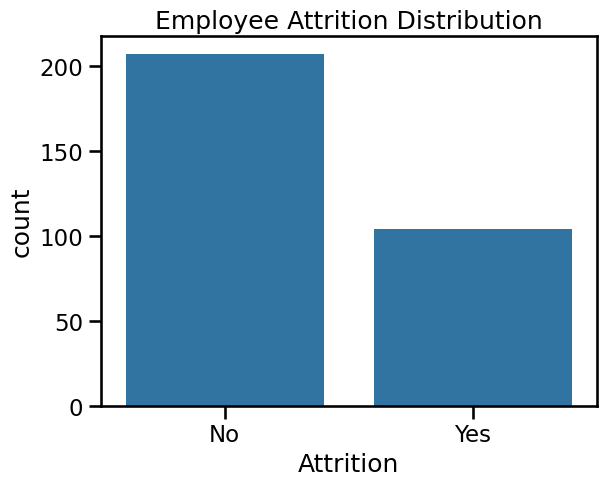

In [8]:
sns.countplot(data=df, x="Attrition")
plt.title("Employee Attrition Distribution")
plt.show()

**Insight:**  
Approximately one-third of employees in the dataset have left the company.
This indicates a non-trivial attrition level, making employee retention
a meaningful and relevant business problem for HR.

## 6. Attrition by Department

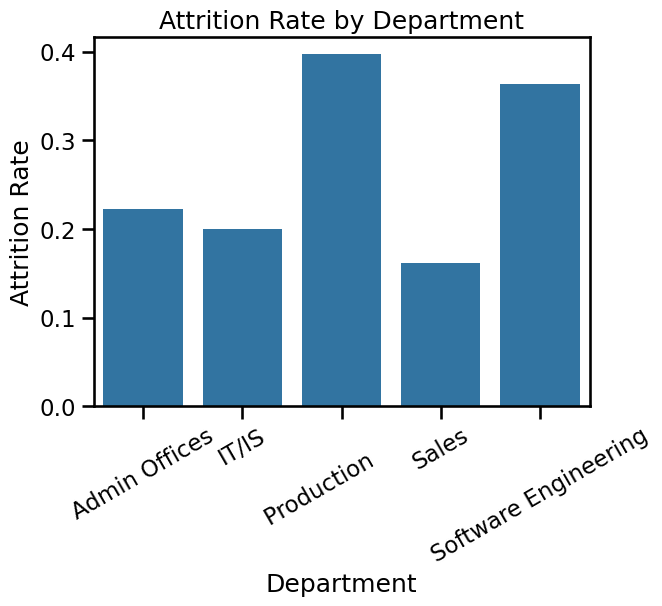

In [9]:
attr_dept = (
    df.groupby("Department")["Attrition"]
    .value_counts(normalize=True)
    .rename("rate")
    .reset_index()
)

attr_dept = attr_dept[attr_dept["Attrition"] == "Yes"]

sns.barplot(data=attr_dept, x="Department", y="rate")
plt.ylabel("Attrition Rate")
plt.title("Attrition Rate by Department")
plt.xticks(rotation=30)
plt.show()

**Insight:**  
Attrition rates differ substantially across departments.
Production and Software Engineering show the highest attrition levels,
suggesting that workload, role-specific stress, or management practices
may be contributing factors.

## 7. Salary vs Attrition

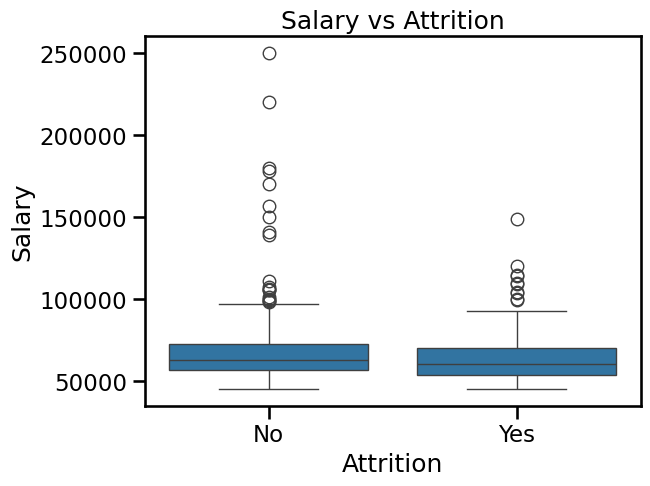

In [10]:
sns.boxplot(data=df, x="Attrition", y="Salary")
plt.title("Salary vs Attrition")
plt.show()

**Insight:**  
Employees who leave the company tend to earn lower salaries on average.
This suggests that compensation competitiveness may play a role in
retention, particularly for employees with marketable skills.

## 8. Employee Satisfaction & Attrition

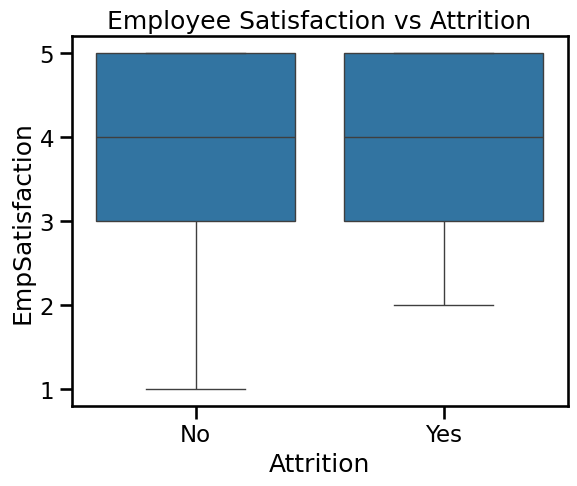

In [11]:
sns.boxplot(data=df, x="Attrition", y="EmpSatisfaction")
plt.title("Employee Satisfaction vs Attrition")
plt.show()

**Insight:**  
Employees with lower satisfaction scores are significantly more likely
to leave the company.
This indicates that satisfaction is a critical early warning signal
for potential attrition.

## 9. Engagement Survey Score

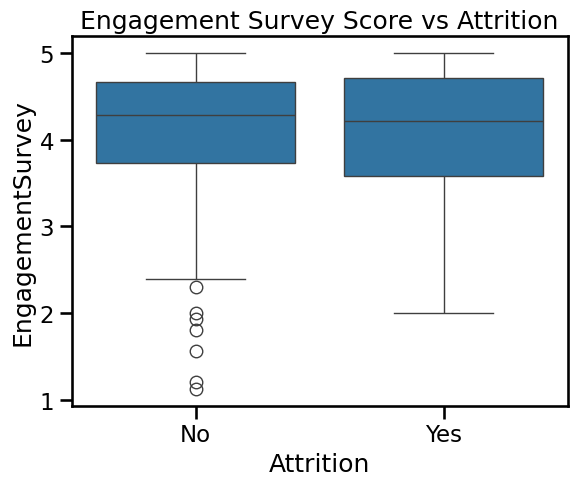

In [12]:
sns.boxplot(data=df, x="Attrition", y="EngagementSurvey")
plt.title("Engagement Survey Score vs Attrition")
plt.show()

**Insight:**  
Lower engagement survey scores are consistently associated with attrition.
This suggests that disengagement often precedes resignation and that
engagement surveys can be used proactively to identify at-risk employees.

## 10. Performance Score & Attrition

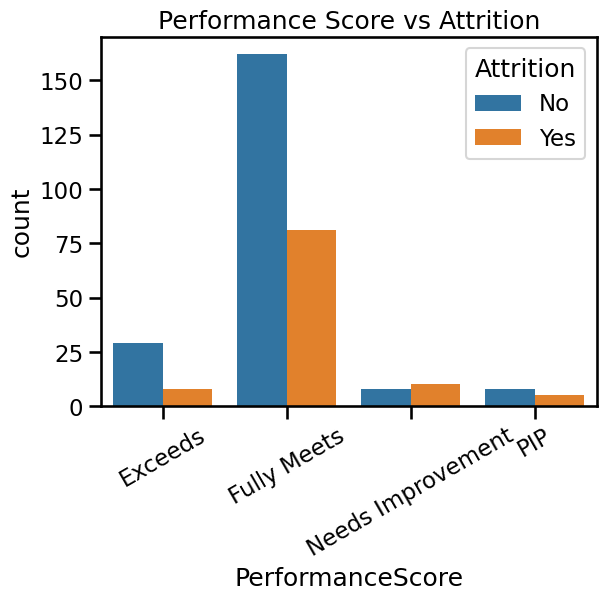

In [13]:
sns.countplot(
    data=df,
    x="PerformanceScore",
    hue="Attrition"
)
plt.xticks(rotation=30)
plt.title("Performance Score vs Attrition")
plt.show()

**Insight:**  
Attrition occurs across all performance levels, including high-performing
employees.
This implies that the company is not only losing low performers, but also
valuable talent, increasing the long-term cost of attrition.

## 11. Absences and Lateness

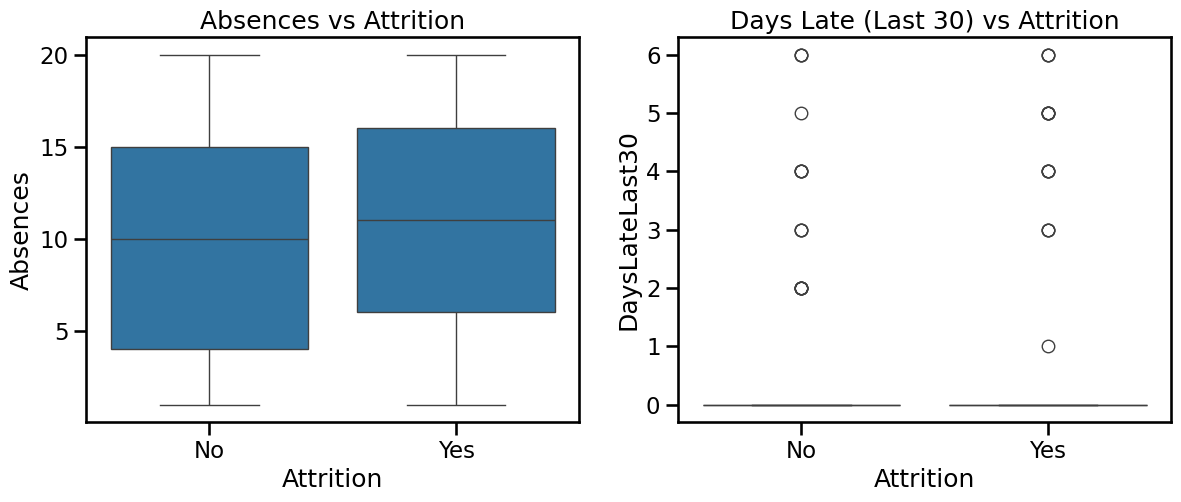

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=df, x="Attrition", y="Absences", ax=axes[0])
axes[0].set_title("Absences vs Attrition")

sns.boxplot(data=df, x="Attrition", y="DaysLateLast30", ax=axes[1])
axes[1].set_title("Days Late (Last 30) vs Attrition")

plt.show()

**Insight:**  
Absences and recent lateness show only weak differences between employees
who leave and those who stay.
These variables may provide limited predictive value on their own but could
still contribute when combined with satisfaction and engagement indicators.

## Key HR Insights (EDA Summary)

- Attrition affects approximately one-third of the workforce, making retention
  a significant business concern.
- Certain departments experience disproportionately higher attrition,
  indicating localized organizational challenges.
- Lower salary, satisfaction, and engagement levels are consistently linked
  to higher attrition risk.
- High-performing employees also leave the company, increasing the strategic
  cost of attrition.
- Behavioral indicators such as absences and lateness provide weaker signals
  compared to attitudinal factors.

These insights highlight the importance of focusing on engagement,
satisfaction, and department-level interventions in future HR strategies.

## Next Steps

- Data cleaning and preprocessing
- Feature engineering (tenure, relative salary, risk indicators)
- Predictive modeling for employee attrition